# **Fatores do Baixo Peso ao Nascer no Rio Grande do Norte**
## Análise Econométrica com Dados do SINASC

O **baixo peso ao nascer (BPN)** — definido pela OMS como peso inferior a **2.500 gramas** — é um indicador de saúde pública de extrema importância por estar associado a morbidades, mortalidade neonatal e repercussões socioeconômicas ao longo da vida. No Brasil, estima-se que cerca de 8% dos nascidos apresentem BPN.

Este notebook reproduz e expande a análise econométrica realizada no trabalho de conclusão de curso *"Fatores do Baixo Peso ao Nascer no Rio Grande do Norte: Análise Econométrica com Dados do SINASC"* (Silva Filho, 2025), utilizando dados públicos das **Declarações de Nascidos Vivos de 2023** do estado do Rio Grande do Norte, disponíveis no [SINASC/DATASUS](https://datasus.saude.gov.br/).

O objetivo é identificar os fatores socioeconômicos e clínicos associados ao BPN e quantificar seus impactos, subsidiando profissionais de saúde e gestores públicos na formulação de políticas voltadas à redução do BPN.

---

**Fonte dos dados:** SINASC — Sistema de Informações sobre Nascidos Vivos. Ministério da Saúde / DATASUS. Declarações de Nascidos Vivos, Rio Grande do Norte, 2023.  
**Referência:** Silva Filho, G. L. (2025). *Fatores do Baixo Peso ao Nascer no Rio Grande do Norte: Análise Econométrica com Dados do SINASC*. UERN, Mossoró.

## **Preparação do Notebook**

In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys, os

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2

import statsmodels.api as sm

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

import shap

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 150,
    }
)

SEED = 42

## **Leitura dos Dados**

Os dados utilizados provêm do **SINASC (Sistema de Informações sobre Nascidos Vivos)**, disponibilizados pelo Ministério da Saúde via [DATASUS](https://datasus.saude.gov.br/). A base cobre as **Declarações de Nascidos Vivos de 2023** para o estado do **Rio Grande do Norte**, com informações sobre gestação, parto, condições do recém-nascido e características socioeconômicas da mãe.

In [2]:
# Dados do SINASC — Declarações de Nascidos Vivos, Rio Grande do Norte, 2023
# Fonte: DATASUS/Ministério da Saúde — https://datasus.saude.gov.br/
df_raw = pd.read_csv("../data/dados.csv", sep=",", low_memory=False)
print(f"Registros carregados: {df_raw.shape[0]:,} | Variáveis: {df_raw.shape[1]}")
df_raw.head(3)

Registros carregados: 15,038 | Variáveis: 17


,ano,sigla_uf,sigla_uf_nome,sexo,peso,id_anomalia,semana_gestacao,tipo_gravidez,tipo_parto,pre_natal_agr,quantidade_filhos_vivos,quantidade_filhos_mortos,idade_mae,escolaridade_mae,estado_civil_mae,raca_cor_mae,gestacoes_ant
0,2023,RN,Rio Grande do Norte,Feminino,2290.0,Não,41.0,Única,Vaginal,7 e mais consultas,0.0,0.0,33,12 e mais,Solteira,Branca,0.0
1,2023,RN,Rio Grande do Norte,Masculino,2700.0,Não,35.0,Única,Vaginal,7 e mais consultas,0.0,0.0,21,8 a 11 anos,Solteira,Parda,0.0
2,2023,RN,Rio Grande do Norte,Feminino,2340.0,NaN,40.0,Única,Vaginal,7 e mais consultas,0.0,0.0,19,8 a 11 anos,União estável,Parda,0.0


## **Tratamento dos Dados**

Foram aplicados os critérios de exclusão utilizados por **Tolio et al. (2020)** e replicados no trabalho de referência:
- Registros com peso inferior a 500g
- Gestações com duração inferior a 22 semanas
- Combinações clinicamente inconsistentes de semana gestacional e peso
- Registros com dados declarados como **ignorados** em qualquer variável analítica
- Gestações múltiplas (gêmeos, trigêmeos etc.)

Após os filtros, a amostra totalizou **13.276 registros** — resultado consistente com o paper de referência.

In [3]:
# Remoção de colunas não utilizadas na análise
df = df_raw.drop(columns=["ano", "sigla_uf_nome", "id_anomalia"])

print(f"Total inicial: {df.shape[0]:,} registros\n")

# Nulos
n_nulos = df.isna().sum().max()
df.dropna(inplace=True)
print(f"Removidos por nulos: {n_nulos}")

# Gravidez múltipla
n_multipla = (df.tipo_gravidez != "Única").sum()
df = df[df.tipo_gravidez == "Única"]
print(f"Removidos (gravidez múltipla): {n_multipla}")

# Peso < 500g
n_peso500 = (df.peso < 500).sum()
df = df[df.peso >= 500]
print(f"Removidos (peso < 500g): {n_peso500}")

# Inconsistências clínicas conforme Tolio et al. (2020)
filtros_clinicos = (
    (df.semana_gestacao < 22)
    | ((df.semana_gestacao.between(22, 27)) & (df.peso > 1500))
    | ((df.semana_gestacao.between(28, 31)) & (df.peso > 2500))
    | ((df.semana_gestacao > 37) & (df.peso < 1500))
)
n_clinicos = filtros_clinicos.sum()
df = df[~filtros_clinicos]
print(f"Removidos (inconsistências clínicas): {n_clinicos}")

# Registros com dados declarados como ignorados
mask_ignorados = ((df == "Ignorado") | (df == "Ignorada") | (df == "Nenhuma")).sum(
    axis=1
) > 0
n_ignorados = mask_ignorados.sum()
df = df[~mask_ignorados].reset_index(drop=True)
print(f"Removidos (dados ignorados): {n_ignorados}")

print(f"\nAmostra final para análise: {df.shape[0]:,} registros")

Total inicial: 15,038 registros

Removidos por nulos: 784
Removidos (gravidez múltipla): 278
Removidos (peso < 500g): 19
Removidos (inconsistências clínicas): 61
Removidos (dados ignorados): 129

Amostra final para análise: 13,276 registros


## **Variável Resposta e Feature Engineering**

A variável resposta `baixo_peso` é binária: 1 se o recém-nascido pesou menos de 2.500g (critério OMS), 0 caso contrário.

As covariáveis categóricas foram construídas com base na literatura:
- **Faixa etária da mãe**: `<20`, `20-24`, `25-29`, `30-34`, `35+` — captura o padrão em "U" descrito na literatura
- **Filhos vivos**: `0`, `1-2`, `3+` — proxy de paridade
- **Histórico de aborto**: binário derivado da quantidade de filhos mortos
- **Estado conjugal**: agrupado em *com companheiro* e *sem companheiro*
- **Cor**: dicotomizada em *Branca* vs *Não Branca*

In [4]:
# Variável resposta: baixo peso ao nascer (peso < 2.500g, critério OMS)
df["baixo_peso"] = np.where(df.peso < 2500, 1, 0)

# Faixa etária da mãe — formato da literatura
df["faixa_idade_mae"] = pd.cut(
    df["idade_mae"],
    bins=[0, 19, 24, 29, 34, 60],
    labels=["<20", "20-24", "25-29", "30-34", "35+"],
    right=True,
)
# Quantidade de filhos vivos — 0, 1-2, 3+
df["faixa_filhos_vivos"] = pd.cut(
    df["quantidade_filhos_vivos"],
    bins=[-1, 0, 2, 20],
    labels=["0", "1-2", "3+"],
    right=True,
)
# Histórico de aborto (binário)
df["historico_aborto"] = np.where(df["quantidade_filhos_mortos"] > 0, "Sim", "Não")

# Situação conjugal agrupada
df["estado_conjugal_grupo"] = np.where(
    df["estado_civil_mae"].isin(["Casada", "União estável"]),
    "Com companheiro",
    "Sem companheiro",
)
# Cor da mãe: branca vs não branca
df["cor_mae_branca"] = np.where(df["raca_cor_mae"] == "Branca", "Branca", "Não Branca")

n_bpn = df.baixo_peso.sum()
taxa_bpn = df.baixo_peso.mean()
print(f"Nascidos com baixo peso: {n_bpn:,} ({taxa_bpn:.2%} da amostra)")

Nascidos com baixo peso: 1,069 (8.05% da amostra)


## **Análise Exploratória**

Antes de modelar, exploramos a distribuição do peso ao nascer e as taxas de BPN por categoria de cada variável explicativa. Isso permite verificar quais fatores apresentam maior desequilíbrio na incidência do desfecho e orientar as expectativas para a modelagem.

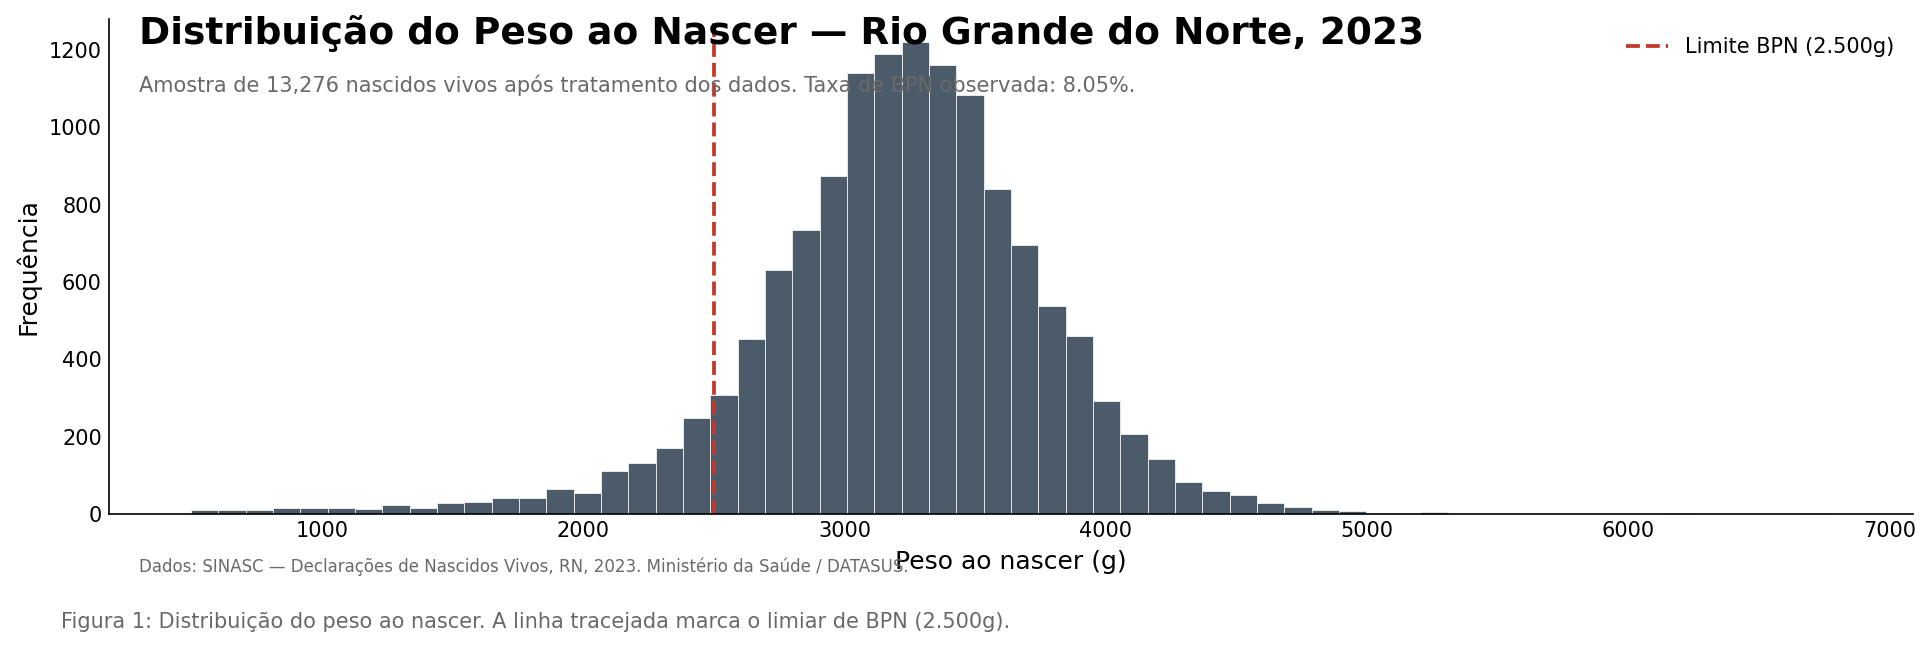

In [5]:
# Funções auxiliares para visualização
fontdict = {"size": 12}


def fmt_pct(value, _):
    return f"{value:.0f}%"


def add_caption(fig, caption):
    fig.text(
        x=0.035, y=-0.06, s=caption, ha="left", va="bottom", fontsize=10, color="dimgray"
    )


def bpn_rate_by_cat(series_col, target_series):
    """Taxa de BPN (%) por categoria."""
    return target_series.groupby(series_col, observed=True).mean().mul(100)


# fig 1: distribuição do peso ao nascer
fig, ax = plt.subplots(figsize=(13, 4))
fig.subplots_adjust(top=0.80, bottom=0.14)

ax.hist(
    df["peso"], bins=60, color="#2c3e50", alpha=0.85, edgecolor="white", linewidth=0.4
)
ax.axvline(
    2500, color="#c0392b", linewidth=1.8, linestyle="--", label="Limite BPN (2.500g)"
)
ax.set_xlabel("Peso ao nascer (g)", fontdict=fontdict)
ax.set_ylabel("Frequência", fontdict=fontdict)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(length=0)

fig.text(
    x=0.075,
    y=0.92,
    s="Distribuição do Peso ao Nascer — Rio Grande do Norte, 2023",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.84,
    s=f"Amostra de {df.shape[0]:,} nascidos vivos após tratamento dos dados. "
    f"Taxa de BPN observada: {df.baixo_peso.mean():.2%}.",
    fontsize=10,
    color="dimgray",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.04,
    s="Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
    fontsize=8,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    "Figura 1: Distribuição do peso ao nascer. A linha tracejada marca o limiar de BPN (2.500g).",
)
plt.tight_layout()
plt.show()

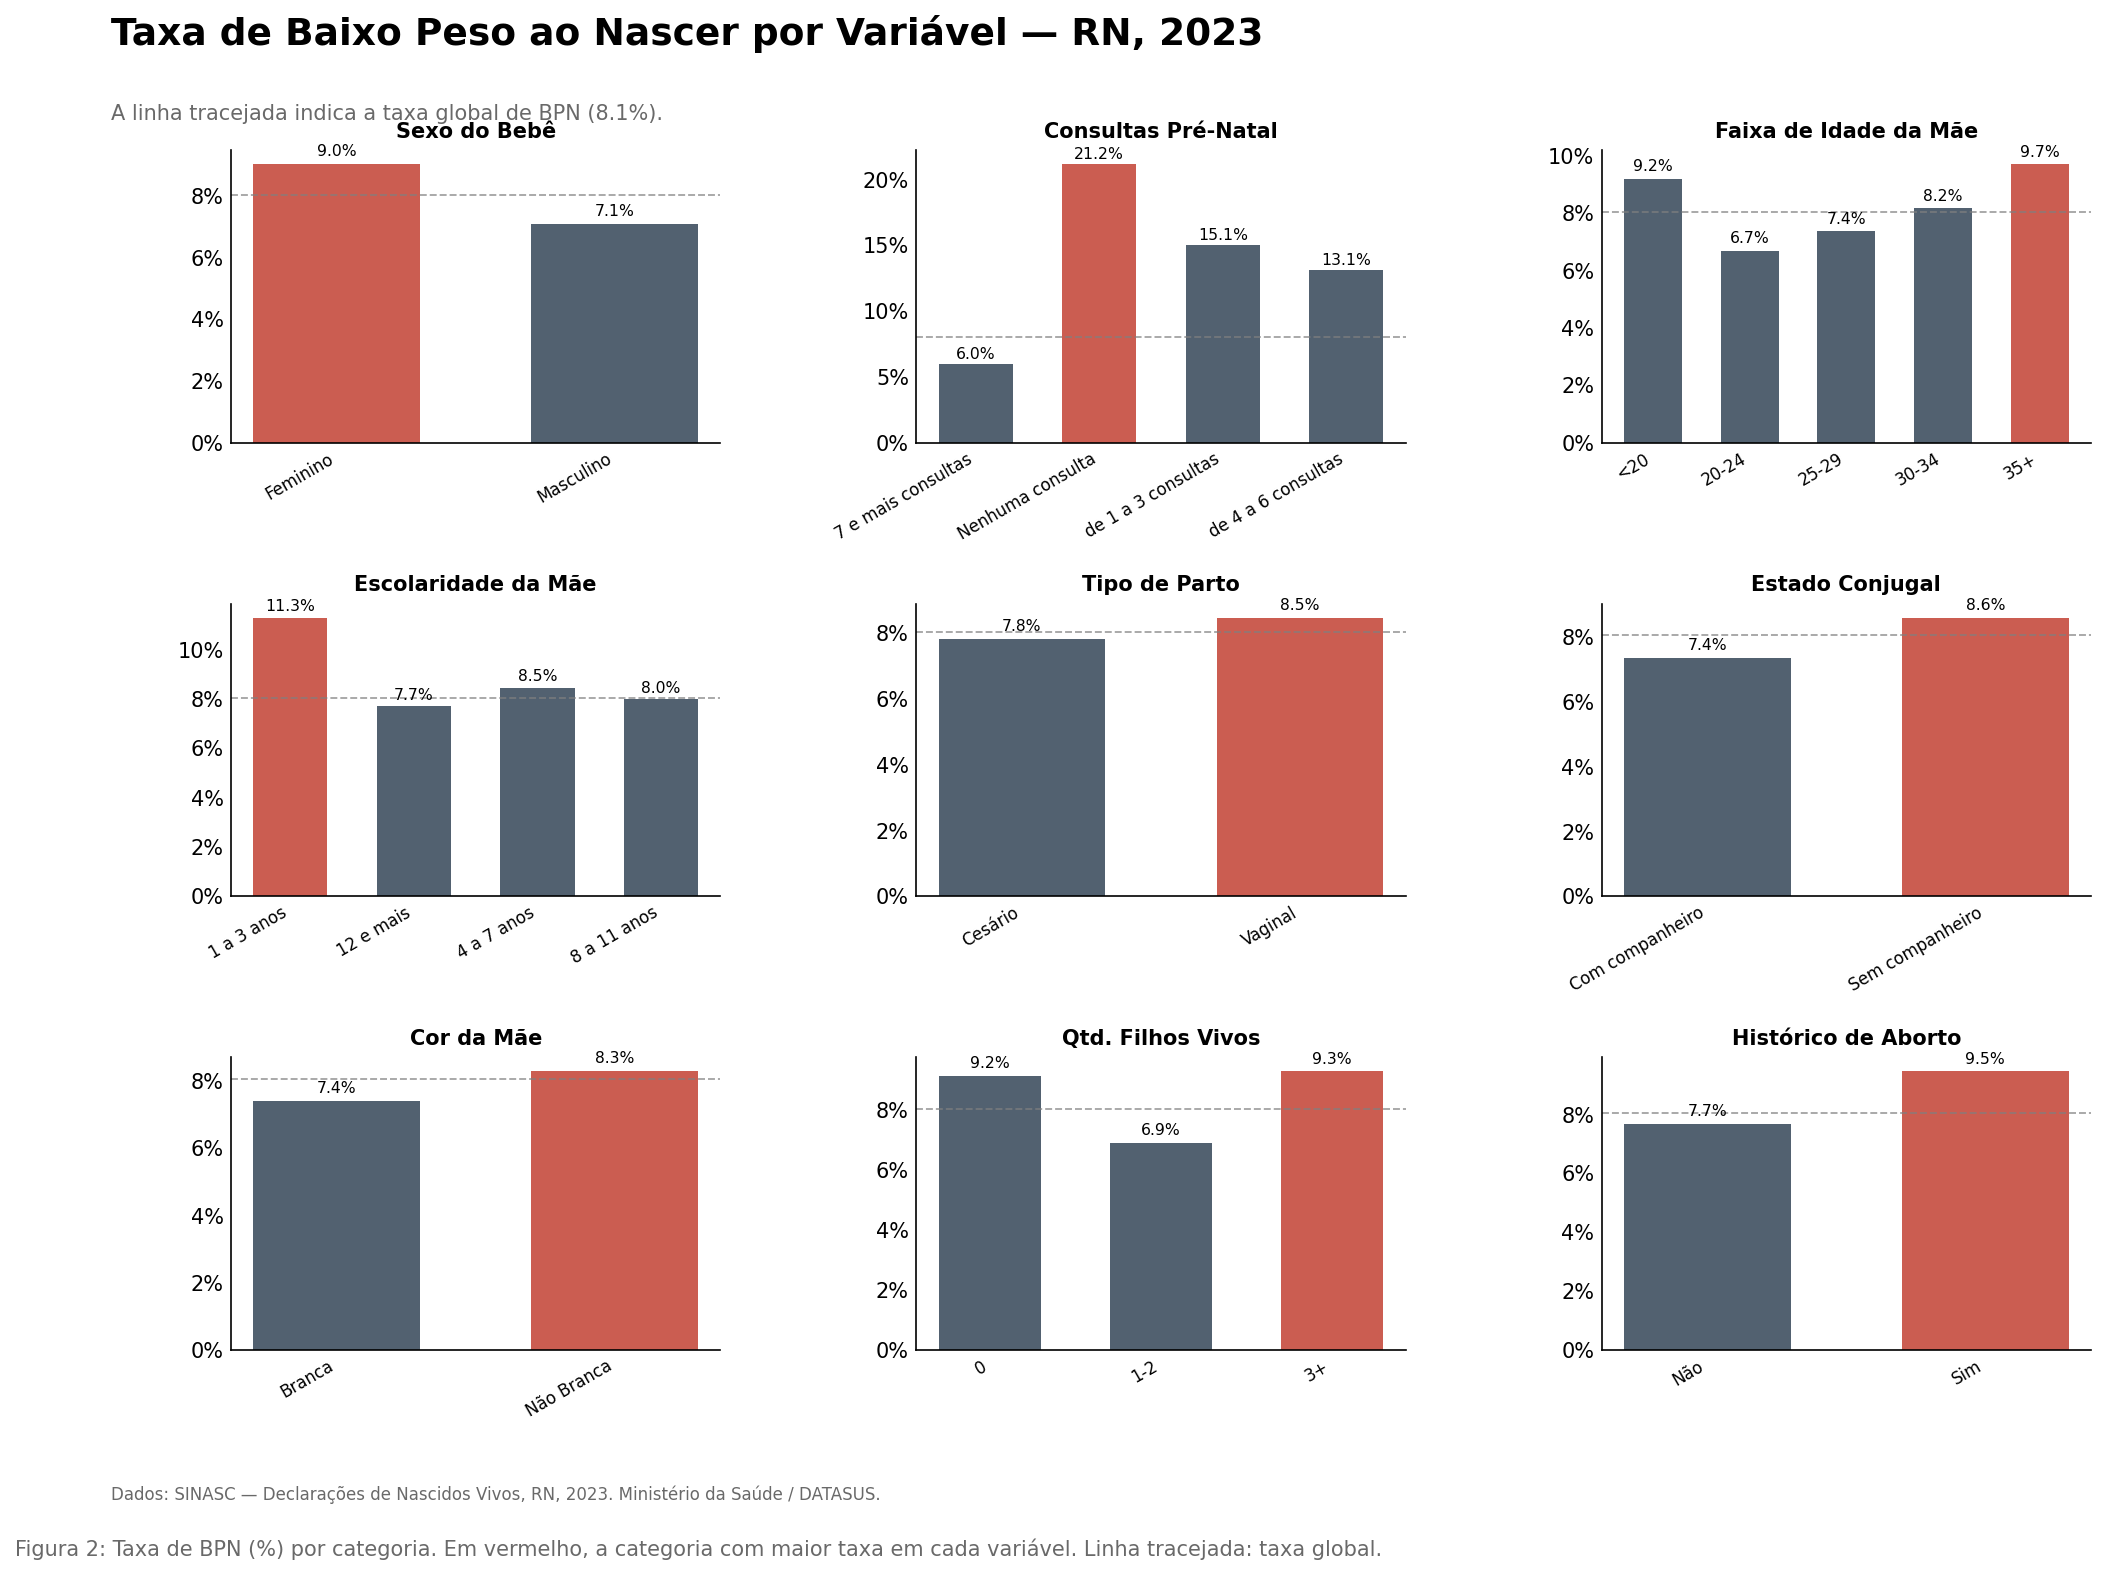

In [6]:
# fig 2: taxa de BPN por categoria — pequenos múltiplos
categorias = {
    "sexo": "Sexo do Bebê",
    "pre_natal_agr": "Consultas Pré-Natal",
    "faixa_idade_mae": "Faixa de Idade da Mãe",
    "escolaridade_mae": "Escolaridade da Mãe",
    "tipo_parto": "Tipo de Parto",
    "estado_conjugal_grupo": "Estado Conjugal",
    "cor_mae_branca": "Cor da Mãe",
    "faixa_filhos_vivos": "Qtd. Filhos Vivos",
    "historico_aborto": "Histórico de Aborto",
}

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.subplots_adjust(hspace=0.55, wspace=0.4, top=0.88, bottom=0.08)

fig.text(
    x=0.075,
    y=0.95,
    s="Taxa de Baixo Peso ao Nascer por Variável — RN, 2023",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.90,
    s=f"A linha tracejada indica a taxa global de BPN ({df.baixo_peso.mean():.1%}).",
    fontsize=10,
    color="dimgray",
    ha="left",
)

for ax, (col, title) in zip(axes.flat, categorias.items()):
    rates = bpn_rate_by_cat(df[col], df["baixo_peso"])
    colors = ["#c0392b" if v == rates.max() else "#2c3e50" for v in rates.values]
    bars = ax.bar(range(len(rates)), rates.values, color=colors, alpha=0.82, width=0.6)
    ax.axhline(
        df.baixo_peso.mean() * 100, color="gray", linewidth=0.9, linestyle="--", alpha=0.7
    )
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, fontsize=8, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(length=0)
    for bar, val in zip(bars, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=7.5,
        )

add_caption(
    fig,
    "Figura 2: Taxa de BPN (%) por categoria. Em vermelho, a categoria com maior taxa em cada variável. "
    "Linha tracejada: taxa global.",
)
fig.text(
    x=0.075,
    y=-0.02,
    s="Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
    fontsize=8,
    color="dimgray",
    ha="left",
)
plt.show()

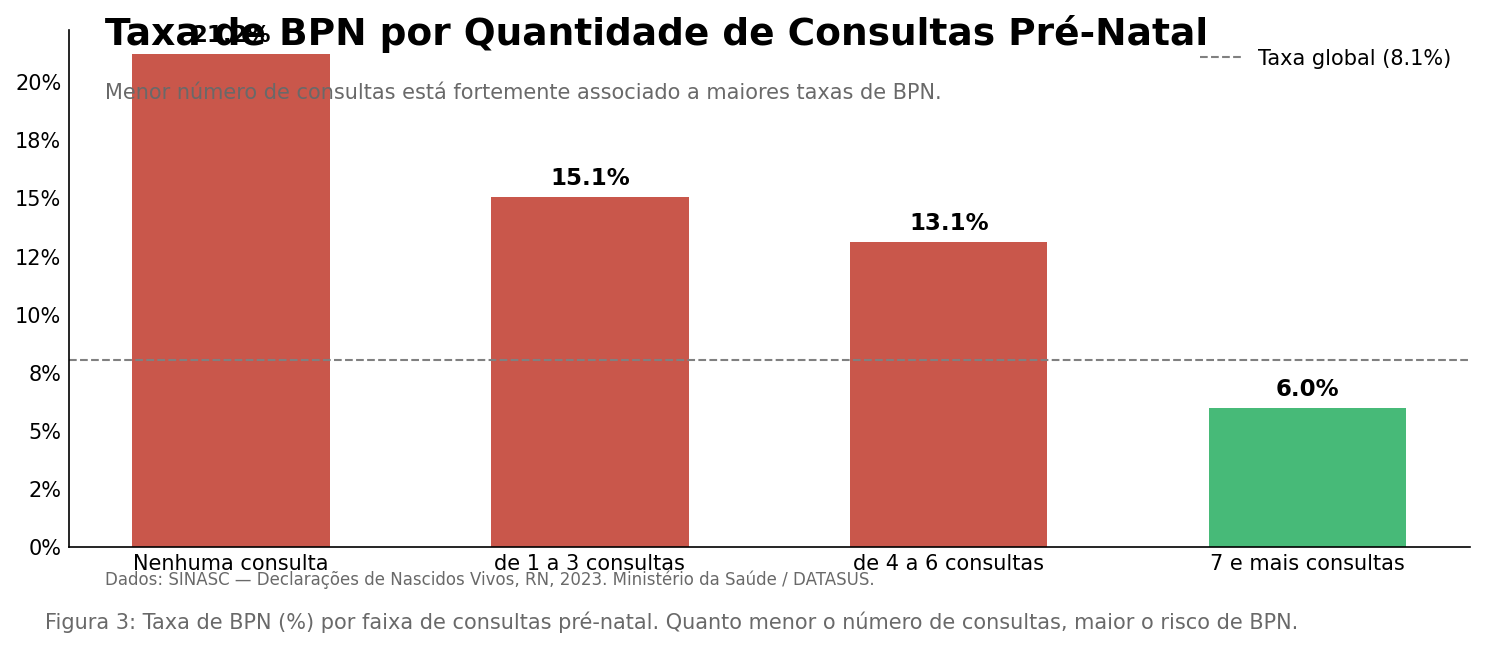

In [7]:
# fig 3: efeito das consultas pré-natal sobre o BPN — destaque analítico
rates_prenatal = bpn_rate_by_cat(df["pre_natal_agr"], df["baixo_peso"])
# Ordenar da menor para maior consulta
ordem = [
    "Nenhuma consulta",
    "de 1 a 3 consultas",
    "de 4 a 6 consultas",
    "7 e mais consultas",
]
rates_prenatal = rates_prenatal.reindex([o for o in ordem if o in rates_prenatal.index])

fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.80, bottom=0.18)

colors = ["#c0392b" if i < 3 else "#27ae60" for i in range(len(rates_prenatal))]
bars = ax.bar(
    range(len(rates_prenatal)),
    rates_prenatal.values,
    color=colors,
    alpha=0.85,
    width=0.55,
)

ax.axhline(
    df.baixo_peso.mean() * 100,
    color="gray",
    linewidth=1,
    linestyle="--",
    label=f"Taxa global ({df.baixo_peso.mean():.1%})",
)
ax.set_xticks(range(len(rates_prenatal)))
ax.set_xticklabels(rates_prenatal.index, fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=10)

for bar, val in zip(bars, rates_prenatal.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

fig.text(
    x=0.075,
    y=0.92,
    s="Taxa de BPN por Quantidade de Consultas Pré-Natal",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.83,
    s="Menor número de consultas está fortemente associado a maiores taxas de BPN.",
    fontsize=10,
    color="dimgray",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.02,
    s="Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
    fontsize=8,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    "Figura 3: Taxa de BPN (%) por faixa de consultas pré-natal. "
    "Quanto menor o número de consultas, maior o risco de BPN.",
)
plt.tight_layout()
plt.show()

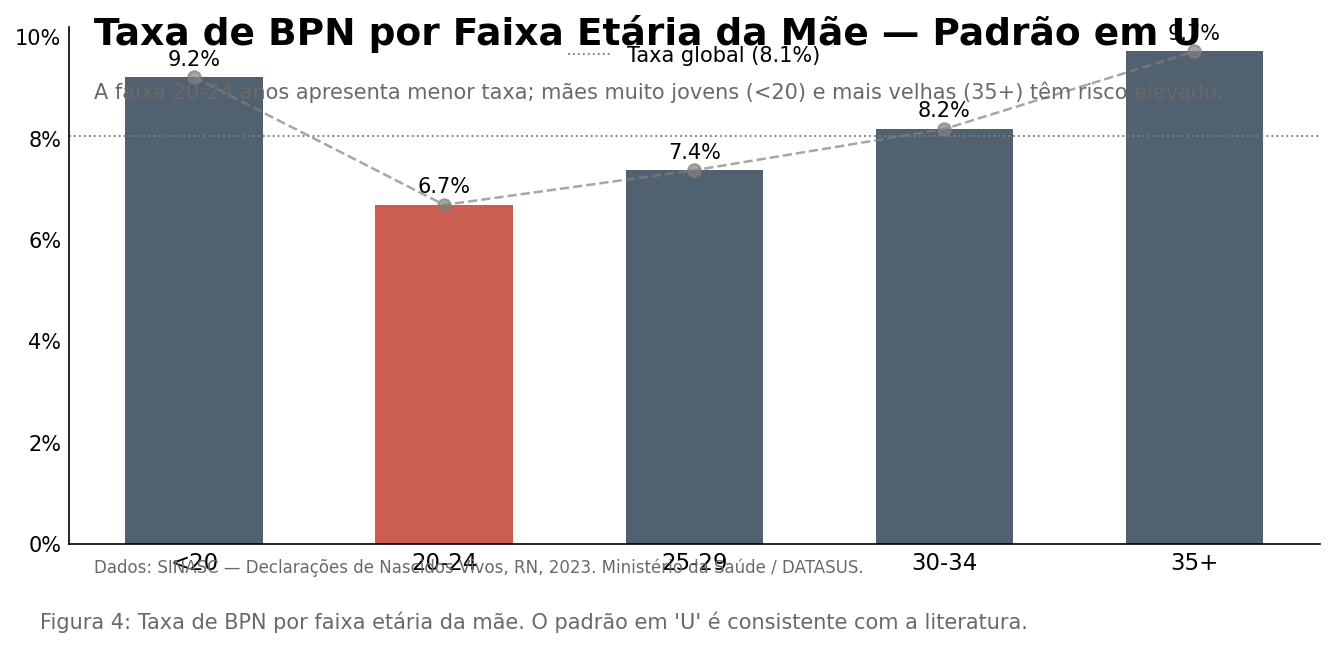

In [8]:
# fig 4: padrão em "U" da idade materna — faixa de risco intermediária menor
rates_age = bpn_rate_by_cat(df["faixa_idade_mae"], df["baixo_peso"])

fig, ax = plt.subplots(figsize=(9, 4))
fig.subplots_adjust(top=0.80, bottom=0.16)

colors = ["#c0392b" if v == rates_age.min() else "#2c3e50" for v in rates_age.values]
bars = ax.bar(
    range(len(rates_age)), rates_age.values, color=colors, alpha=0.82, width=0.55
)
ax.plot(
    range(len(rates_age)),
    rates_age.values,
    "o--",
    color="gray",
    linewidth=1.2,
    markersize=6,
    alpha=0.7,
)
ax.axhline(
    df.baixo_peso.mean() * 100,
    color="gray",
    linewidth=0.9,
    linestyle=":",
    label=f"Taxa global ({df.baixo_peso.mean():.1%})",
)
ax.set_xticks(range(len(rates_age)))
ax.set_xticklabels(rates_age.index, fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=10)

for bar, val in zip(bars, rates_age.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.text(
    x=0.075,
    y=0.92,
    s="Taxa de BPN por Faixa Etária da Mãe — Padrão em U",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.83,
    s="A faixa 20-24 anos apresenta menor taxa; mães muito jovens (<20) e mais velhas (35+) têm risco elevado.",
    fontsize=10,
    color="dimgray",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.04,
    s="Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
    fontsize=8,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    "Figura 4: Taxa de BPN por faixa etária da mãe. O padrão em 'U' é consistente com a literatura.",
)
plt.tight_layout()
plt.show()

## **Modelagem**

Dois modelos são comparados:
1. **Regressão Logística** — modelo econométrico clássico, com seleção de variáveis via *backward stepwise* baseada no teste de razão de verossimilhança (LR). Oferece interpretação direta via *odds ratios* (OR).
2. **CatBoost** — modelo de *gradient boosting* com suporte nativo a variáveis categóricas e balanceamento automático de classes. Oferece maior poder preditivo a custo de interpretação mais indireta, compensada pelo uso de valores SHAP.

A divisão treino/teste é **80/20**, estratificada pelo desfecho, garantindo que ambos os modelos sejam avaliados nas mesmas observações.

In [9]:
# Variáveis categóricas e numéricas para modelagem
CATEGORICAS = [
    "sexo",
    "tipo_parto",
    "pre_natal_agr",
    "faixa_idade_mae",
    "escolaridade_mae",
    "estado_conjugal_grupo",
    "cor_mae_branca",
    "faixa_filhos_vivos",
    "historico_aborto",
]
NUMERICA = ["semana_gestacao"]
TARGET = "baixo_peso"

df_model = df[[TARGET] + NUMERICA + CATEGORICAS].copy()

# Divisão treino/teste estratificada (80/20)
train_idx, test_idx = train_test_split(
    df_model.index, test_size=0.2, random_state=SEED, stratify=df_model[TARGET]
)
y_train = df_model.loc[train_idx, TARGET].astype(float)
y_test = df_model.loc[test_idx, TARGET].astype(float)

# --- Encoding para Regressão Logística ---
# Categorias de referência: menor taxa de BPN (conforme paper)
REFERENCIAS = {
    col: bpn_rate_by_cat(df_model[col], df_model[TARGET]).idxmin() for col in CATEGORICAS
}

dummies = pd.get_dummies(df_model[CATEGORICAS], drop_first=False, dtype=float)
cols_ref = [
    f"{col}_{ref}"
    for col, ref in REFERENCIAS.items()
    if f"{col}_{ref}" in dummies.columns
]
dummies = dummies.drop(columns=cols_ref)

X_lr = pd.concat([df_model[NUMERICA], dummies], axis=1)
X_train_lr = X_lr.loc[train_idx]
X_test_lr = X_lr.loc[test_idx]

# --- Dataset para CatBoost (features categóricas nativas) ---
X_cat = df_model[NUMERICA + CATEGORICAS].copy()
X_cat[CATEGORICAS] = X_cat[CATEGORICAS].astype(str)
X_train_cat = X_cat.loc[train_idx]
X_test_cat = X_cat.loc[test_idx]

print(f"Treino: {len(train_idx):,} registros | Teste: {len(test_idx):,} registros")
print(f"Taxa de BPN — treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")
print(f"\nVariáveis de referência (omitidas no modelo LR):")
for col, ref in REFERENCIAS.items():
    print(f"  {col}: {ref}")

Treino: 10,620 registros | Teste: 2,656 registros
Taxa de BPN — treino: 8.05% | teste: 8.06%

Variáveis de referência (omitidas no modelo LR):
  sexo: Masculino
  tipo_parto: Cesário
  pre_natal_agr: 7 e mais consultas
  faixa_idade_mae: 20-24
  escolaridade_mae: 12 e mais
  estado_conjugal_grupo: Com companheiro
  cor_mae_branca: Branca
  faixa_filhos_vivos: 1-2
  historico_aborto: Não


### **Regressão Logística**

O modelo de regressão logística estima a probabilidade de BPN em função das covariáveis. A seleção de variáveis via *backward stepwise* com teste LR (nível de significância $\alpha = 0{,}05$) garante parcimônia, mantendo apenas variáveis que contribuem significativamente para o ajuste.

Os coeficientes são apresentados como **odds ratios (OR)** — razão de chances — com intervalo de confiança de 95%. Um OR = 1,5, por exemplo, indica que a chance de BPN é 50% maior na categoria analisada em relação à categoria de referência.

In [10]:
def backward_stepwise_lr(X, y, alpha=0.05):
    """
    Seleção backward stepwise via teste de razão de verossimilhança (LR).
    Remove iterativamente a variável com p-valor LR mais alto enquanto > alpha.
    """
    features = list(X.columns)

    while features:
        X_full = sm.add_constant(X[features], has_constant="add")
        model_full = sm.GLM(y, X_full, family=sm.families.Binomial()).fit(disp=False)

        # p-valor LR para cada variável: quanto a log-verossimilhança cai sem ela
        p_values = {}
        for feat in features:
            remaining = [f for f in features if f != feat]
            X_red = (
                sm.add_constant(X[remaining], has_constant="add")
                if remaining
                else pd.DataFrame({"const": np.ones(len(y))}, index=X.index)
            )
            model_red = sm.GLM(y, X_red, family=sm.families.Binomial()).fit(disp=False)
            lr_stat = 2 * (model_full.llf - model_red.llf)
            p_values[feat] = 1 - chi2.cdf(lr_stat, df=1)

        worst = max(p_values, key=p_values.get)
        if p_values[worst] > alpha:
            features.remove(worst)
        else:
            break

    X_final = sm.add_constant(X[features], has_constant="add")
    return sm.GLM(y, X_final, family=sm.families.Binomial()).fit(disp=False), features


# Executar seleção backward stepwise no conjunto de treino
model_lr, selected_features = backward_stepwise_lr(X_train_lr, y_train)

print(f"Variáveis selecionadas ({len(selected_features)}):")
for f in selected_features:
    print(f"  {f}")

Variáveis selecionadas (8):
  semana_gestacao
  sexo_Feminino
  pre_natal_agr_Nenhuma consulta
  pre_natal_agr_de 1 a 3 consultas
  pre_natal_agr_de 4 a 6 consultas
  faixa_idade_mae_30-34
  faixa_idade_mae_35+
  faixa_filhos_vivos_0


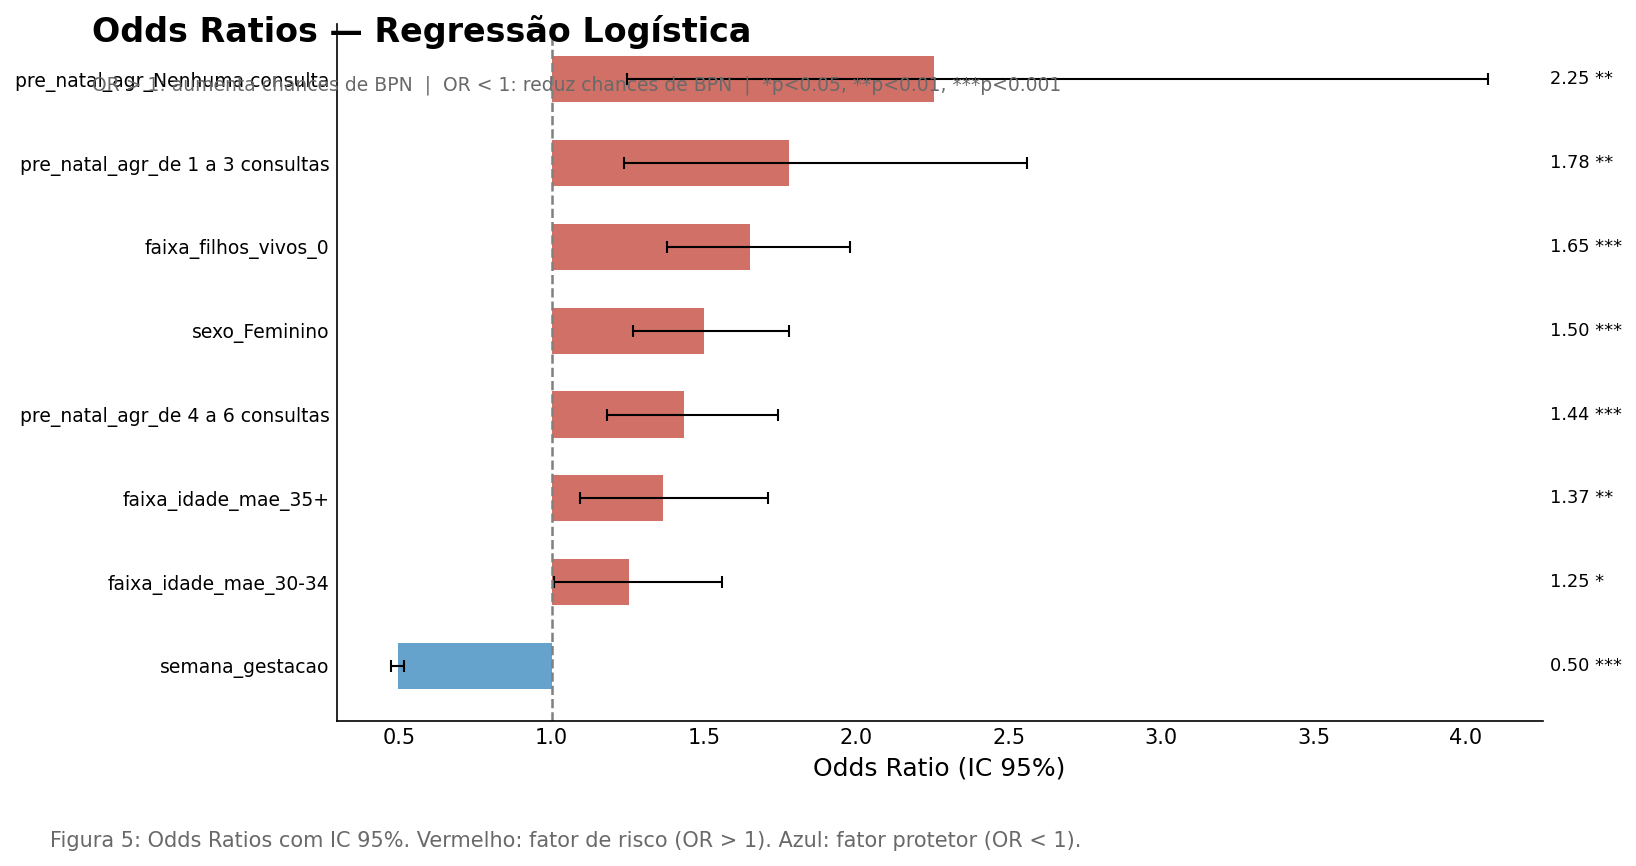

In [11]:
def plot_odds_ratio(model, title="Odds Ratios — Regressão Logística"):
    """Forest plot de Odds Ratios com IC 95%."""
    params = model.params.drop("const")
    conf = model.conf_int().drop("const")
    p_vals = model.pvalues.drop("const")

    or_df = pd.DataFrame(
        {
            "OR": np.exp(params),
            "lower": np.exp(conf[0]),
            "upper": np.exp(conf[1]),
            "p_value": p_vals,
        }
    ).sort_values("OR")

    fig, ax = plt.subplots(figsize=(11, max(5, len(or_df) * 0.48 + 1.5)))
    fig.subplots_adjust(left=0.38, right=0.92, top=0.88, bottom=0.1)

    fig.text(x=0.06, y=0.95, s=title, fontsize=16, fontweight="bold", ha="left")
    fig.text(
        x=0.06,
        y=0.89,
        s="OR > 1: aumenta chances de BPN  |  OR < 1: reduz chances de BPN  |  *p<0.05, **p<0.01, ***p<0.001",
        fontsize=9,
        color="dimgray",
        ha="left",
    )

    y_pos = list(range(len(or_df)))
    colors = ["#c0392b" if v > 1 else "#2980b9" for v in or_df["OR"]]

    ax.barh(y_pos, or_df["OR"] - 1, left=1, color=colors, alpha=0.72, height=0.55)
    ax.errorbar(
        or_df["OR"],
        y_pos,
        xerr=[or_df["OR"] - or_df["lower"], or_df["upper"] - or_df["OR"]],
        fmt="none",
        color="black",
        capsize=3,
        linewidth=1,
    )
    ax.axvline(1, color="gray", linewidth=1.2, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(or_df.index, fontsize=9)
    ax.set_xlabel("Odds Ratio (IC 95%)", fontdict=fontdict)
    ax.tick_params(length=0)

    x_max = or_df["upper"].max()
    for i, (_, row) in enumerate(or_df.iterrows()):
        sig = (
            "***"
            if row["p_value"] < 0.001
            else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else ""
        )
        ax.text(x_max * 1.05, i, f"{row['OR']:.2f} {sig}", va="center", fontsize=8.5)

    add_caption(
        fig,
        "Figura 5: Odds Ratios com IC 95%. "
        "Vermelho: fator de risco (OR > 1). Azul: fator protetor (OR < 1).",
    )
    plt.tight_layout()
    plt.show()


plot_odds_ratio(model_lr)

In [12]:
def evaluate_model(model_name, y_true, y_prob, threshold=0.5):
    """Métricas de avaliação: AUC, sensibilidade, especificidade, VPP, VPN."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Modelo": model_name,
        "AUC": roc_auc_score(y_true, y_prob),
        "Sensibilidade": tp / (tp + fn),
        "Especificidade": tn / (tn + fp),
        "VPP": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "VPN": tn / (tn + fn),
    }


# Regressão Logística — predição no teste
X_test_lr_const = sm.add_constant(X_test_lr[selected_features], has_constant="add")
y_prob_lr = model_lr.predict(X_test_lr_const)

metrics_lr = evaluate_model("Regressão Logística", y_test, y_prob_lr)
print("Regressão Logística — métricas no conjunto de teste:")
for k, v in metrics_lr.items():
    if k != "Modelo":
        print(f"  {k}: {v:.3f}")

Regressão Logística — métricas no conjunto de teste:
  AUC: 0.876
  Sensibilidade: 0.327
  Especificidade: 0.988
  VPP: 0.707
  VPN: 0.944


### **CatBoost**

O **CatBoost** é um algoritmo de *gradient boosting* que lida nativamente com variáveis categóricas sem necessidade de *one-hot encoding* prévio, sendo mais robusto a dados tabulares mistos. O parâmetro `auto_class_weights="Balanced"` compensa automaticamente o desbalanceamento de classes (~8% de BPN vs 92% sem BPN).

A comparação com a regressão logística permite avaliar o trade-off entre poder preditivo e interpretabilidade — aspecto central para subsidiar políticas públicas.

In [13]:
# CatBoost com balanceamento automático de classes
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    random_seed=SEED,
    verbose=0,
    auto_class_weights="Balanced",
    eval_metric="AUC",
)
catboost_model.fit(X_train_cat, y_train, cat_features=CATEGORICAS)

y_prob_cat = catboost_model.predict_proba(X_test_cat)[:, 1]
metrics_cat = evaluate_model("CatBoost", y_test, y_prob_cat)

print("CatBoost — métricas no conjunto de teste:")
for k, v in metrics_cat.items():
    if k != "Modelo":
        print(f"  {k}: {v:.3f}")

CatBoost — métricas no conjunto de teste:
  AUC: 0.877
  Sensibilidade: 0.776
  Especificidade: 0.822
  VPP: 0.276
  VPN: 0.977



Métricas comparativas no conjunto de teste:


,AUC,Sensibilidade,Especificidade,VPP,VPN
Modelo,,,,,
Regressão Logística,0.876,0.327,0.988,0.707,0.944
CatBoost,0.877,0.776,0.822,0.276,0.977


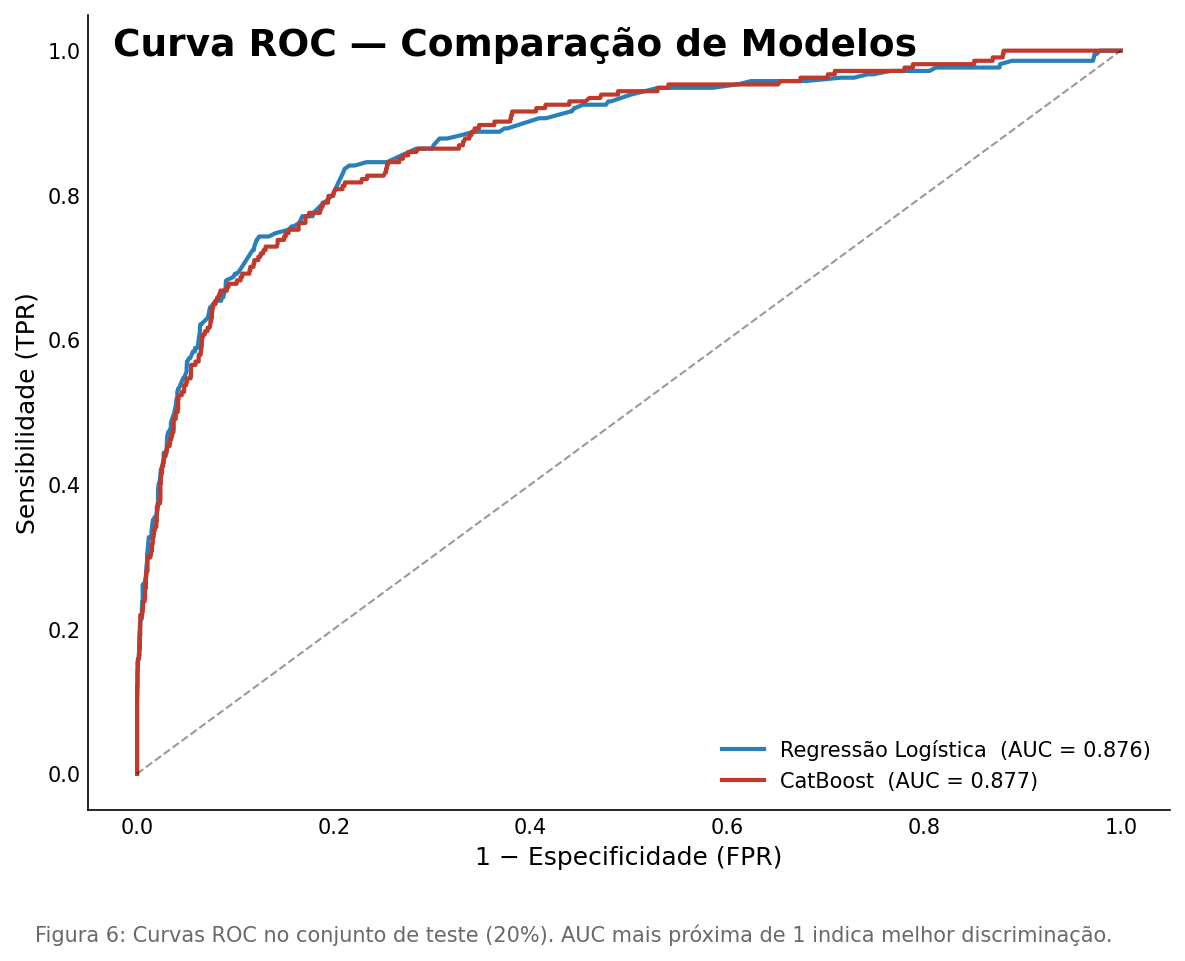

In [15]:
# fig 6: comparação de curvas ROC — Regressão Logística vs CatBoost
metrics_df = pd.DataFrame([metrics_lr, metrics_cat]).set_index("Modelo")

fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(top=0.85, bottom=0.12)

cores = {"Regressão Logística": "#2980b9", "CatBoost": "#c0392b"}
for modelo, color in cores.items():
    y_prob = y_prob_lr if modelo == "Regressão Logística" else y_prob_cat
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{modelo}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4)
ax.set_xlabel("1 − Especificidade (FPR)", fontdict=fontdict)
ax.set_ylabel("Sensibilidade (TPR)", fontdict=fontdict)
ax.legend(frameon=False, fontsize=10, loc="lower right")
ax.tick_params(length=0)

fig.text(
    x=0.1,
    y=0.93,
    s="Curva ROC — Comparação de Modelos",
    fontsize=18,
    fontweight="bold",
    ha="left",
)

add_caption(
    fig,
    "Figura 6: Curvas ROC no conjunto de teste (20%). AUC mais próxima de 1 indica melhor discriminação.",
)

# Tabela de métricas
print("\nMétricas comparativas no conjunto de teste:")
display(metrics_df.map(lambda x: f"{x:.3f}"))

plt.tight_layout()
plt.show()

## **Explicabilidade**

Para subsidiar decisões de política pública, a interpretabilidade dos modelos é essencial. Usamos duas abordagens complementares:

1. **Odds Ratios (Regressão Logística)**: já apresentados na Figura 4. Indicam diretamente *quanto a chance de BPN aumenta ou diminui* por categoria, com intervalos de confiança robustos.

2. **SHAP (SHapley Additive exPlanations)**: método baseado na teoria dos jogos que atribui a cada variável a sua contribuição marginal para cada predição individual. Aplicado ao CatBoost, combina o poder preditivo do modelo com interpretabilidade local e global.

O **SHAP** é especialmente adequado para contextos de saúde pública porque:
- Revela **a direção** do efeito de cada variável (aumenta ou reduz o risco)
- Permite análise **individual** (qual variável mais influenciou um caso específico) e **agregada** (quais variáveis são mais importantes no geral)
- Os resultados são **comparáveis** com os odds ratios da regressão logística, validando a consistência entre modelos

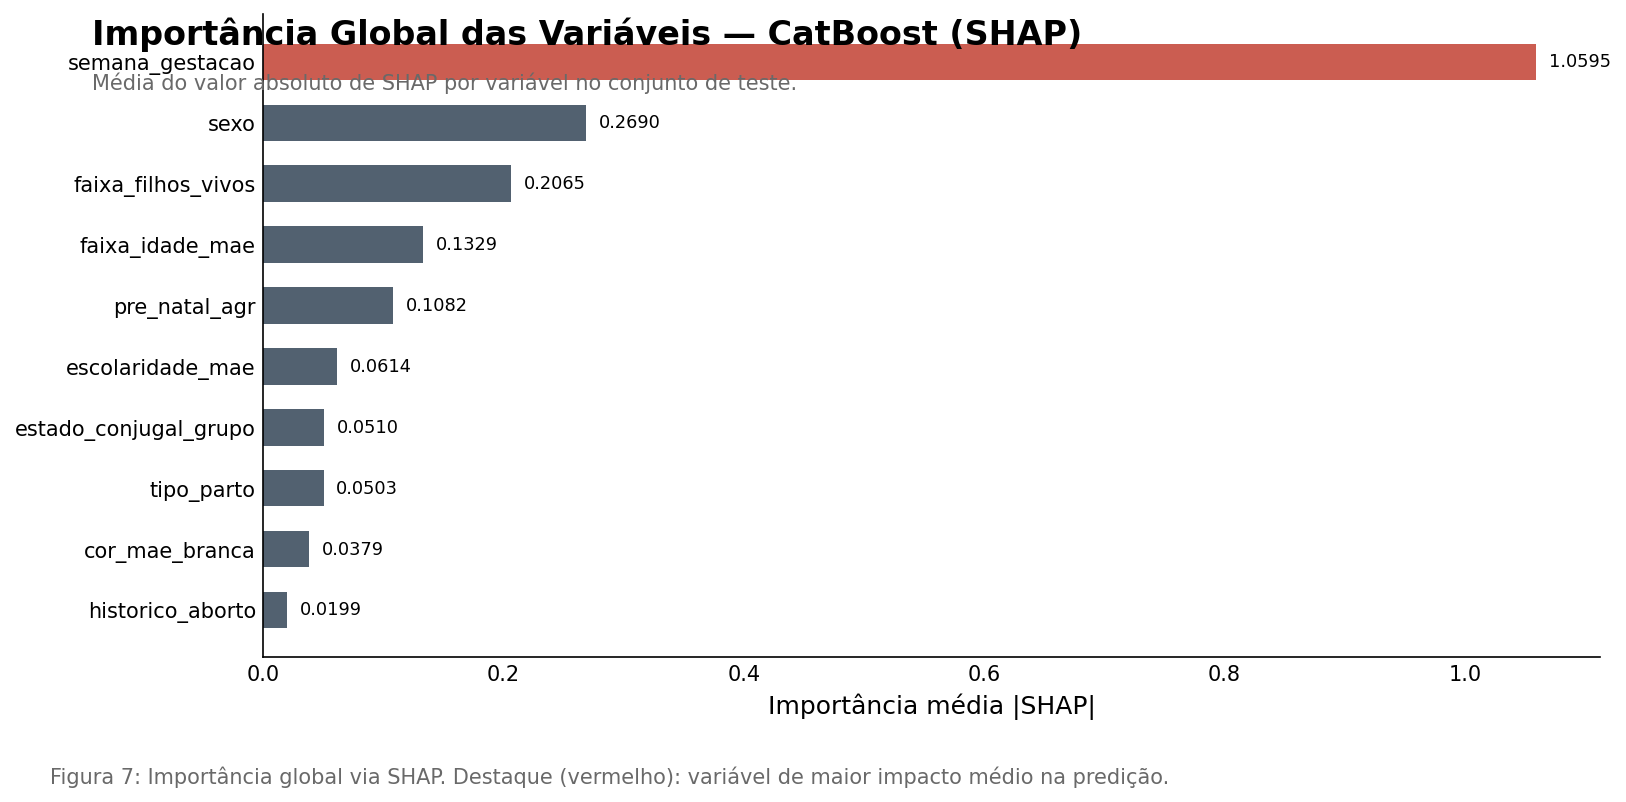

In [16]:
# Calcular SHAP values para o CatBoost no conjunto de teste
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test_cat)

# fig 7: importância global das variáveis via SHAP (mean |SHAP|)
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test_cat.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
fig.subplots_adjust(left=0.28, top=0.85, bottom=0.12, right=0.95)

colors = ["#c0392b" if v == mean_shap.max() else "#2c3e50" for v in mean_shap.values]
ax.barh(range(len(mean_shap)), mean_shap.values, color=colors, alpha=0.82, height=0.6)
ax.set_yticks(range(len(mean_shap)))
ax.set_yticklabels(mean_shap.index, fontsize=10)
ax.set_xlabel("Importância média |SHAP|", fontdict=fontdict)
ax.tick_params(length=0)

for i, val in enumerate(mean_shap.values):
    ax.text(val + mean_shap.max() * 0.01, i, f"{val:.4f}", va="center", fontsize=8.5)

fig.text(
    x=0.06,
    y=0.93,
    s="Importância Global das Variáveis — CatBoost (SHAP)",
    fontsize=16,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.06,
    y=0.87,
    s="Média do valor absoluto de SHAP por variável no conjunto de teste.",
    fontsize=10,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    "Figura 7: Importância global via SHAP. Destaque (vermelho): variável de maior impacto médio na predição.",
)
plt.tight_layout()
plt.show()

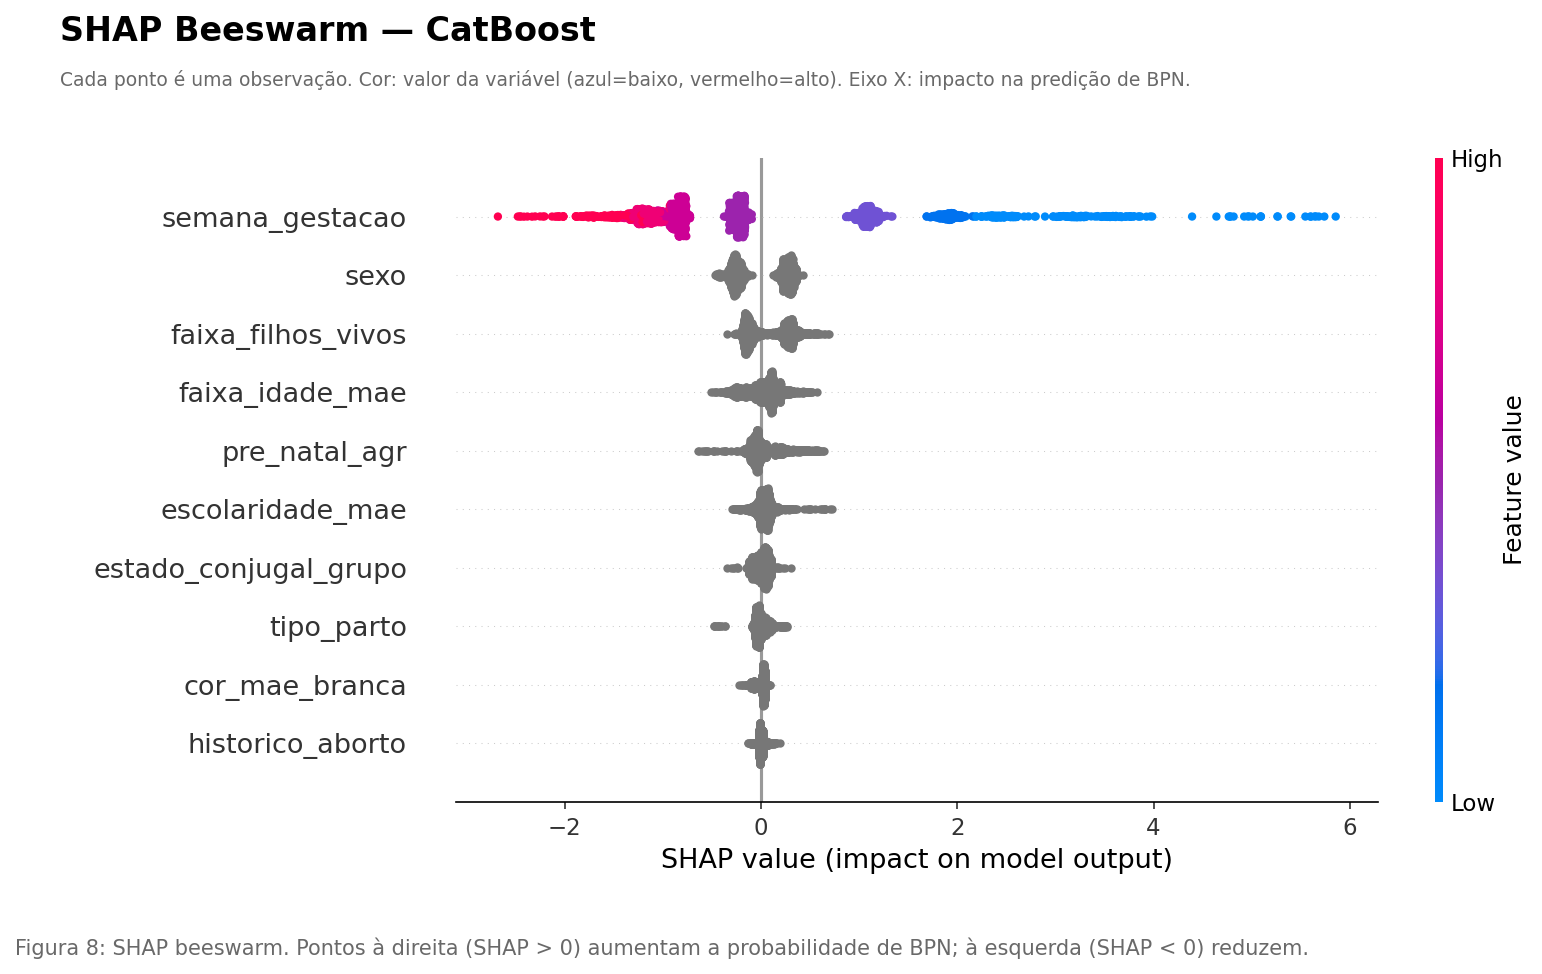

In [17]:
# fig 8: SHAP beeswarm — direção e magnitude do efeito de cada variável
shap.summary_plot(shap_values, X_test_cat, max_display=10, show=False)

fig = plt.gcf()
fig.set_size_inches(12, 6)
fig.subplots_adjust(top=0.83, left=0.28, right=0.92)

fig.text(
    x=0.06,
    y=0.96,
    s="SHAP Beeswarm — CatBoost",
    fontsize=16,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.06,
    y=0.91,
    s="Cada ponto é uma observação. Cor: valor da variável (azul=baixo, vermelho=alto). "
    "Eixo X: impacto na predição de BPN.",
    fontsize=9,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    "Figura 8: SHAP beeswarm. Pontos à direita (SHAP > 0) aumentam a probabilidade de BPN; "
    "à esquerda (SHAP < 0) reduzem.",
)
plt.show()

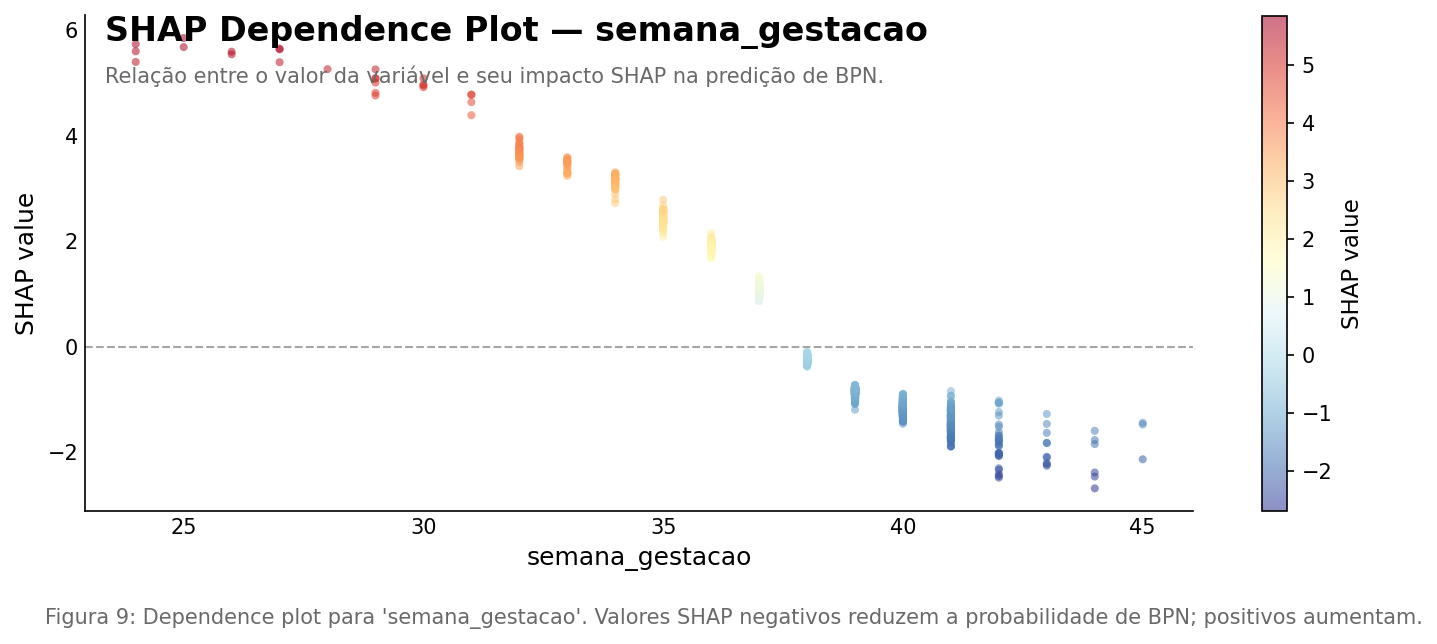

In [18]:
# fig 9: SHAP dependence plot — variável de maior impacto global
top_var = mean_shap.idxmax()
top_shap = shap_values[:, X_test_cat.columns.get_loc(top_var)]

fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.82, bottom=0.15)

sc = ax.scatter(
    X_test_cat[top_var],
    top_shap,
    c=top_shap,
    cmap="RdYlBu_r",
    alpha=0.55,
    s=15,
    linewidths=0,
)
ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7)
plt.colorbar(sc, ax=ax, label="SHAP value")
ax.set_xlabel(top_var, fontdict=fontdict)
ax.set_ylabel("SHAP value", fontdict=fontdict)
ax.tick_params(length=0)

fig.text(
    x=0.075,
    y=0.92,
    s=f"SHAP Dependence Plot — {top_var}",
    fontsize=16,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.85,
    s="Relação entre o valor da variável e seu impacto SHAP na predição de BPN.",
    fontsize=10,
    color="dimgray",
    ha="left",
)

add_caption(
    fig,
    f"Figura 9: Dependence plot para '{top_var}'. "
    "Valores SHAP negativos reduzem a probabilidade de BPN; positivos aumentam.",
)
plt.tight_layout()
plt.show()

## **Conclusões**

Os resultados da análise econométrica confirmam os achados da literatura nacional sobre os fatores associados ao baixo peso ao nascer no Rio Grande do Norte:

- **Semanas de gestação** é o fator de maior impacto individual — cada semana adicional reduz significativamente o risco de BPN. Tanto a regressão logística quanto o CatBoost/SHAP concordam nesse ponto.
- **Consultas pré-natal** apresentam forte gradiente: gestantes com nenhuma ou poucas consultas têm risco substancialmente maior. Isso sinaliza a importância da atenção básica e do acesso à saúde para populações vulneráveis.
- **Sexo feminino** aumenta o risco de BPN — achado consistente com a literatura.
- **Histórico de aborto** e **ausência de filhos vivos anteriores** também elevam o risco, indicando que o histórico reprodutivo merece atenção especial no acompanhamento pré-natal.
- **Idade materna avançada** (30-34 e 35+) aumenta o risco em comparação com mães de 20-24 anos.

Do ponto de vista de **política pública**, os resultados reforçam a necessidade de:
1. **Fortalecer a atenção básica** e garantir acesso ao pré-natal completo (≥7 consultas), especialmente em populações vulneráveis
2. **Priorizar atenção especializada** para gestantes com histórico de aborto, primigestas e mães com 35+ anos
3. **Monitorar prematuridade** como principal fator de risco clínico

A combinação dos dois modelos (Logística + CatBoost/SHAP) permite tanto a **interpretação causal estruturada** quanto a **identificação de padrões complexos**, sendo complementares para a tomada de decisão baseada em evidências.

## **Referências**

**Trabalho de referência:**  
Silva Filho, G. L. (2025). *Fatores do Baixo Peso ao Nascer no Rio Grande do Norte: Análise Econométrica com Dados do SINASC*. UERN, Mossoró.

---

**Dados:**  
SINASC — Sistema de Informações sobre Nascidos Vivos. Ministério da Saúde / DATASUS. Declarações de Nascidos Vivos, Rio Grande do Norte, 2023. Disponível em: https://datasus.saude.gov.br/

---

**Metodologia:**  
Hosmer, D., Lemeshow, S. e Sturdivant, R. X. (2013). *Applied Logistic Regression*. 3rd Edition, Wiley. https://doi.org/10.1002/9781118548387  

Tolio, F. B., Moraes, A. B. e Jacobi, L. F. (2020). *Identificação de fatores de risco para o baixo peso ao nascer — uma análise de regressão logística*. Ciência e Natura, 42, e23. https://doi.org/10.5902/2179460X40497  

Prokhorenkova, L. et al. (2018). *CatBoost: unbiased boosting with categorical features*. Advances in Neural Information Processing Systems, 31.  

Lundberg, S. M. e Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems, 30.

---

**Literatura sobre BPN no Brasil:**  
Carniel, E. F. et al. (2008). *Determinantes do baixo peso ao nascer a partir das Declarações de Nascidos Vivos*. Revista Brasileira de Epidemiologia, 11(1), 169–179.  

Moreira, A. I. M., Sousa, P. R. M. e Sarno, F. (2018). *Baixo peso ao nascer e seus fatores associados*. einstein (São Paulo), 16(4), eAO4251.